# derivatives — H along depth and along (depth × space)

`field_stack` already showed `∇H` and `∇²H` (spatial) and `ΔH` (first
discrete depth derivative). The L4→L5 phase transition observed in
`depth_curves.png` says the interesting axis is **depth**, not space.
This notebook adds:

- `∂H/∂L` per (layer, patch) — continuous-style depth derivative via
  `np.gradient` along the L axis.
- `∂²H/∂L²` per (layer, patch) — concavity along depth.
- Per-patch `H(L)` trajectories — every patch's depth profile, all 196
  overlaid, plus the mean and 5/95-percentile envelope per image.
- Mixed `∂(∇H)/∂L` (rate-of-change of the spatial gradient with depth)
  summed in magnitude across depth — where in the patch grid is the
  field most non-stationary?

Output: `results/{image}/derivatives.png` per image, plus a
cross-image `results/depth_derivatives_summary.png` overlay.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

try:
    NB_DIR = Path(__file__).resolve().parent
except NameError:
    NB_DIR = Path.cwd()
REPO = NB_DIR if (NB_DIR / "pyproject.toml").exists() else NB_DIR.parent
RESULTS = REPO / "results"
IMAGES = REPO / "images"
N_BLOCKS = 12
GRID = 14

names = sorted(d.name for d in RESULTS.iterdir() if (d / "entropies.npz").exists())
print(f"images: {len(names)}  →  {names}")

images: 8  →  ['cluttered', 'occlusion', 'single_object', 'symmetric', 'synth_checker', 'synth_gabor', 'synth_gradient', 'synth_texture_split']


In [2]:
def load_H(name: str) -> np.ndarray:
    return np.load(RESULTS / name / "entropies.npz")["H"]   # (12, 14, 14)


def derivatives(H: np.ndarray):
    """Returns a dict of depth derivatives."""
    dH_dL = np.gradient(H, axis=0)                 # (L, 14, 14)
    d2H_dL2 = np.gradient(dH_dL, axis=0)           # (L, 14, 14)
    # spatial gradient per layer
    gy = np.gradient(H, axis=1)                    # (L, 14, 14)
    gx = np.gradient(H, axis=2)                    # (L, 14, 14)
    grad_mag = np.hypot(gy, gx)                    # (L, 14, 14)
    # mixed: how does the spatial-gradient magnitude evolve across L?
    d_grad_dL = np.gradient(grad_mag, axis=0)      # (L, 14, 14)
    return {
        "dH_dL": dH_dL,
        "d2H_dL2": d2H_dL2,
        "grad_mag": grad_mag,
        "d_grad_dL": d_grad_dL,
    }

## Per-image figure: depth-derivatives stack

In [3]:
def plot_one(name: str) -> None:
    H = load_H(name)
    D = derivatives(H)
    img_pil = Image.open(IMAGES / f"{name}.jpg").convert("RGB")
    layers = np.arange(1, N_BLOCKS + 1)

    # Row 0: image + summary trajectory plot
    fig = plt.figure(figsize=(15, 2.0 * N_BLOCKS + 3.0))
    gs = fig.add_gridspec(N_BLOCKS + 1, 5,
                          height_ratios=[1.4] + [1.0] * N_BLOCKS,
                          hspace=0.18, wspace=0.10)

    ax_img = fig.add_subplot(gs[0, 0])
    ax_img.imshow(img_pil); ax_img.set_title(f"input: {name}", fontsize=10)
    ax_img.axis("off")

    # Per-patch H(L) trajectories
    ax_traj = fig.add_subplot(gs[0, 1:])
    H_flat = H.reshape(N_BLOCKS, -1)           # (12, 196)
    for p in range(H_flat.shape[1]):
        ax_traj.plot(layers, H_flat[:, p], color="0.6", lw=0.4, alpha=0.35)
    H_mean = H_flat.mean(axis=1)
    H_lo = np.percentile(H_flat, 5, axis=1)
    H_hi = np.percentile(H_flat, 95, axis=1)
    ax_traj.fill_between(layers, H_lo, H_hi, color="tab:orange", alpha=0.30,
                         label="5–95 pctile")
    ax_traj.plot(layers, H_mean, "tab:orange", lw=2.2, label="mean")
    ax_traj.axhline(0.5 * np.log(2 * np.pi * np.e), color="k", lw=0.8, ls="--",
                    label="Gaussian baseline")
    ax_traj.set_title(f"H(L) trajectory — every patch", fontsize=10)
    ax_traj.set_xlabel("layer"); ax_traj.set_ylabel("H (nats)")
    ax_traj.legend(fontsize=8, loc="lower left")
    ax_traj.set_xticks(layers)

    # Fixed scales (per image, across layers).
    vlim = lambda a: float(np.max(np.abs(a)) or 1e-6)
    v_dH = vlim(D["dH_dL"])
    v_d2H = vlim(D["d2H_dL2"])
    v_grad = float(D["grad_mag"].max()) or 1e-6
    v_dgrad = vlim(D["d_grad_dL"])

    for L in range(N_BLOCKS):
        # ∂H/∂L
        ax = fig.add_subplot(gs[L + 1, 0])
        ax.imshow(D["dH_dL"][L], vmin=-v_dH, vmax=v_dH, cmap="RdBu_r")
        ax.set_ylabel(f"L{L+1}", fontsize=10, rotation=0, ha="right",
                      va="center", labelpad=10)
        ax.set_xticks([]); ax.set_yticks([])
        if L == 0: ax.set_title("∂H/∂L", fontsize=10)

        # ∂²H/∂L²
        ax = fig.add_subplot(gs[L + 1, 1])
        ax.imshow(D["d2H_dL2"][L], vmin=-v_d2H, vmax=v_d2H, cmap="RdBu_r")
        ax.set_xticks([]); ax.set_yticks([])
        if L == 0: ax.set_title("∂²H/∂L²", fontsize=10)

        # |∇H|
        ax = fig.add_subplot(gs[L + 1, 2])
        ax.imshow(D["grad_mag"][L], vmin=0, vmax=v_grad, cmap="viridis")
        ax.set_xticks([]); ax.set_yticks([])
        if L == 0: ax.set_title("|∇H|", fontsize=10)

        # ∂|∇H|/∂L
        ax = fig.add_subplot(gs[L + 1, 3])
        ax.imshow(D["d_grad_dL"][L], vmin=-v_dgrad, vmax=v_dgrad, cmap="RdBu_r")
        ax.set_xticks([]); ax.set_yticks([])
        if L == 0: ax.set_title("∂|∇H|/∂L", fontsize=10)

        # cumulative |∂H/∂L| up through L
        ax = fig.add_subplot(gs[L + 1, 4])
        cum = np.abs(D["dH_dL"][:L + 1]).sum(axis=0)
        ax.imshow(cum, cmap="magma")
        ax.set_xticks([]); ax.set_yticks([])
        if L == 0: ax.set_title("Σ_{1..L} |∂H/∂L|", fontsize=10)

    fig.suptitle(f"{name} — depth derivatives  (RdBu = signed, fixed per-image vmax)",
                 y=1.0)
    fig.savefig(RESULTS / name / "derivatives.png", dpi=180, bbox_inches="tight")
    plt.close(fig)
    print(f"  wrote {name}/derivatives.png")


for n in names:
    plot_one(n)

  wrote cluttered/derivatives.png


  wrote occlusion/derivatives.png


  wrote single_object/derivatives.png


  wrote symmetric/derivatives.png


  wrote synth_checker/derivatives.png


  wrote synth_gabor/derivatives.png


  wrote synth_gradient/derivatives.png


  wrote synth_texture_split/derivatives.png


## Cross-image summary: input image paired with H(L) trajectories

saved /home/varun/research/eris/results/depth_derivatives_summary.png


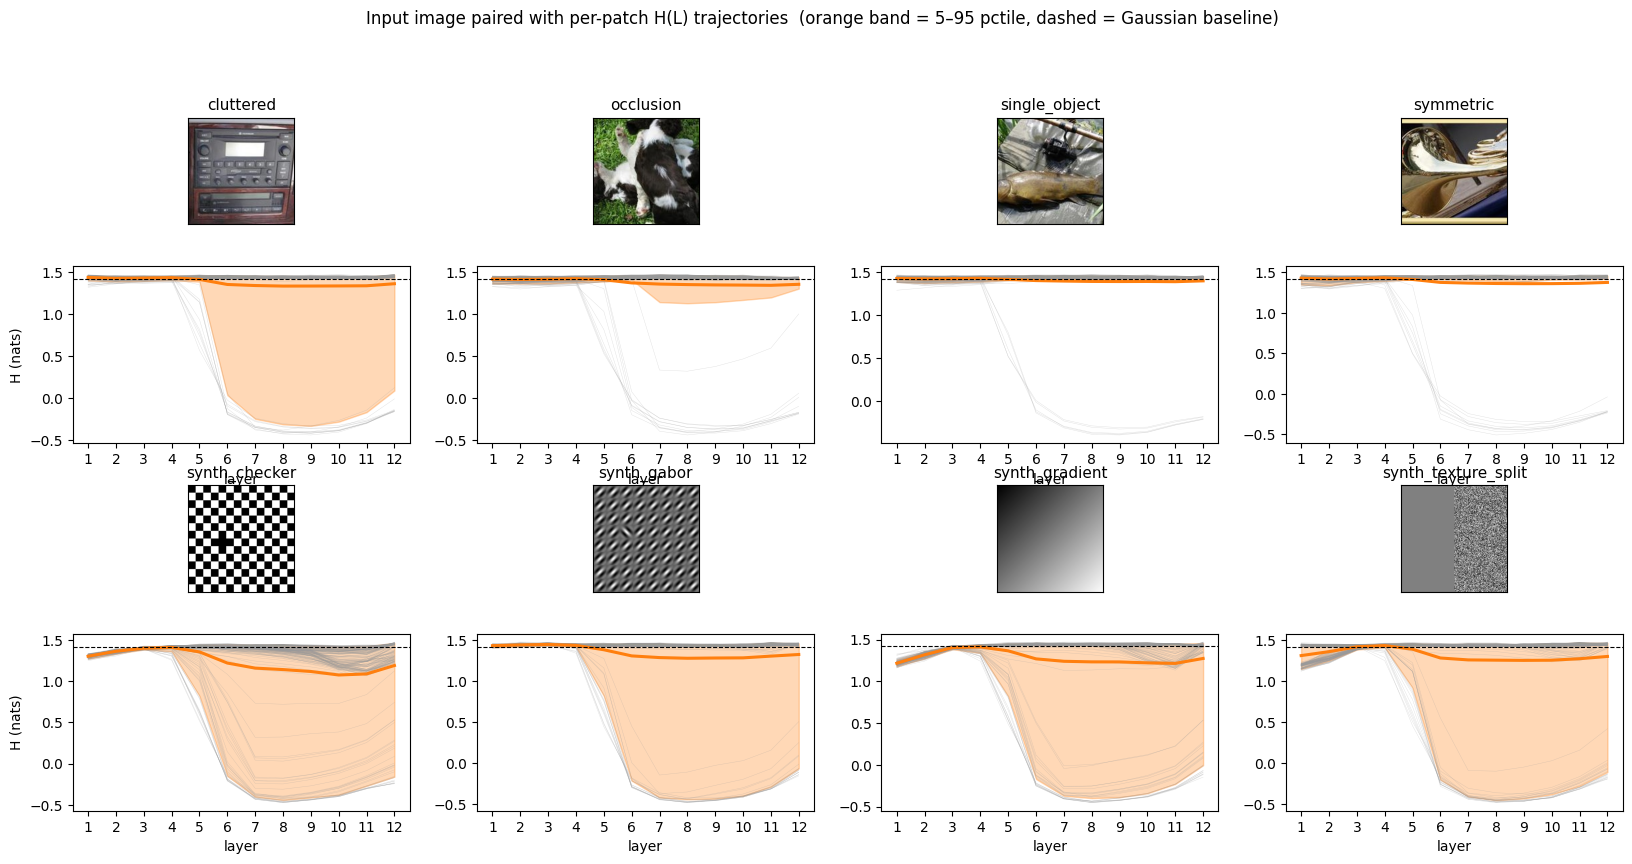

In [4]:
gauss = 0.5 * np.log(2 * np.pi * np.e)
n = len(names)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig = plt.figure(figsize=(20, 4.5 * nrows))
# Each cell is image-on-top + trajectory-below. Use a 2×ncols-per-row gridspec
# nested layout via height_ratios.
gs = fig.add_gridspec(2 * nrows, ncols, height_ratios=[0.6, 1.0] * nrows,
                      hspace=0.30, wspace=0.20)

for idx, name in enumerate(names):
    r = idx // ncols
    c = idx % ncols
    ax_img = fig.add_subplot(gs[2 * r, c])
    ax_img.imshow(Image.open(IMAGES / f"{name}.jpg").convert("RGB"))
    ax_img.set_title(name, fontsize=11)
    ax_img.set_xticks([]); ax_img.set_yticks([])

    ax_traj = fig.add_subplot(gs[2 * r + 1, c])
    H = load_H(name)
    H_flat = H.reshape(N_BLOCKS, -1)
    layers = np.arange(1, N_BLOCKS + 1)
    for p in range(H_flat.shape[1]):
        ax_traj.plot(layers, H_flat[:, p], color="0.6", lw=0.3, alpha=0.30)
    ax_traj.fill_between(layers,
                         np.percentile(H_flat, 5, axis=1),
                         np.percentile(H_flat, 95, axis=1),
                         color="tab:orange", alpha=0.30)
    ax_traj.plot(layers, H_flat.mean(axis=1), "tab:orange", lw=2.2)
    ax_traj.axhline(gauss, color="k", lw=0.8, ls="--")
    ax_traj.set_xlabel("layer")
    if c == 0:
        ax_traj.set_ylabel("H (nats)")
    ax_traj.set_xticks(layers)

fig.suptitle("Input image paired with per-patch H(L) trajectories  "
             "(orange band = 5–95 pctile, dashed = Gaussian baseline)", y=1.0)
fig.savefig(RESULTS / "depth_derivatives_summary.png", dpi=160, bbox_inches="tight")
print(f"saved {RESULTS / 'depth_derivatives_summary.png'}")

## Where is the L4→L5 jump localised? (per-patch ∂H/∂L at L=5, paired
with each input image)

saved /home/varun/research/eris/results/L4_L5_jump_localisation.png


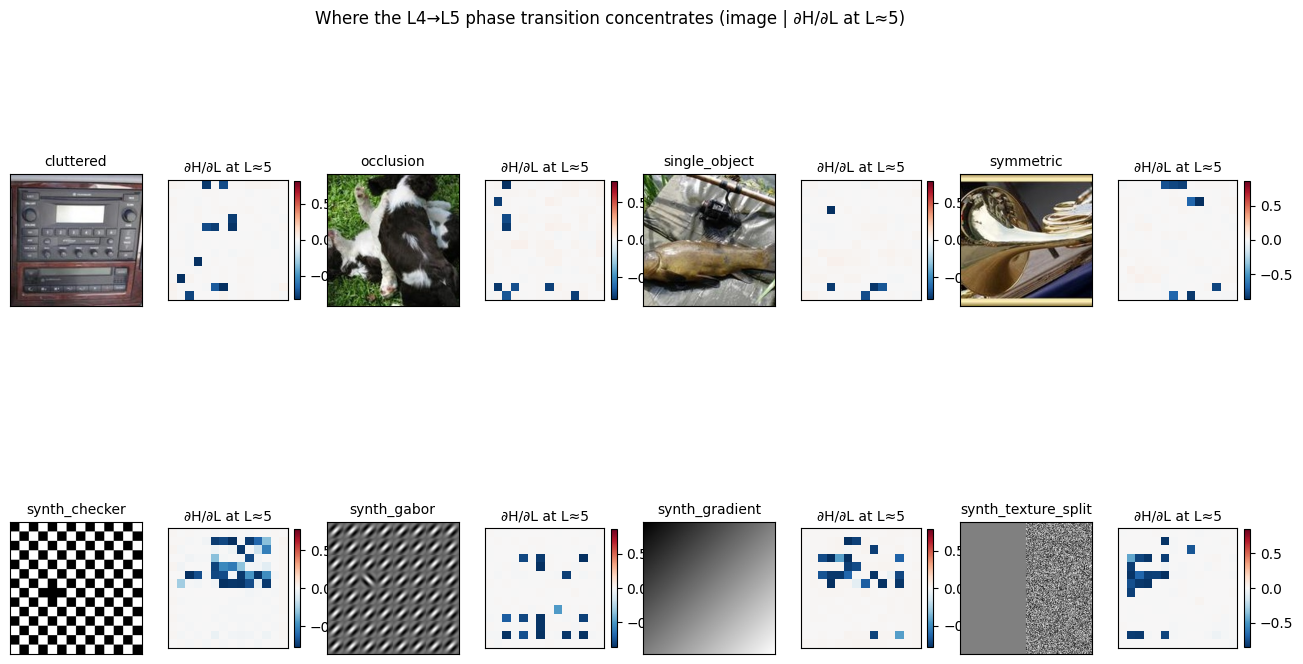

In [5]:
n = len(names)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig = plt.figure(figsize=(16, 4.0 * nrows))
gs = fig.add_gridspec(nrows, ncols * 2, wspace=0.20, hspace=0.30)

for idx, name in enumerate(names):
    r = idx // ncols
    c = idx % ncols
    H = load_H(name)
    dHdL = np.gradient(H, axis=0)
    field = dHdL[4]                                # ∂H/∂L at L≈5
    v = float(np.max(np.abs(field)) or 1e-6)

    # Image (left)
    ax_img = fig.add_subplot(gs[r, 2 * c])
    ax_img.imshow(Image.open(IMAGES / f"{name}.jpg").convert("RGB"))
    ax_img.set_title(name, fontsize=10)
    ax_img.set_xticks([]); ax_img.set_yticks([])

    # ∂H/∂L field (right)
    ax_f = fig.add_subplot(gs[r, 2 * c + 1])
    im = ax_f.imshow(field, vmin=-v, vmax=v, cmap="RdBu_r")
    ax_f.set_title("∂H/∂L at L≈5", fontsize=10)
    ax_f.set_xticks([]); ax_f.set_yticks([])
    fig.colorbar(im, ax=ax_f, fraction=0.045)

fig.suptitle("Where the L4→L5 phase transition concentrates "
             "(image | ∂H/∂L at L≈5)", y=1.0)
fig.savefig(RESULTS / "L4_L5_jump_localisation.png", dpi=160, bbox_inches="tight")
print(f"saved {RESULTS / 'L4_L5_jump_localisation.png'}")